In [32]:
# Import Libraries

import pandas as pd
import os
import pickle
import leidenalg as la
import igraph as ig
import networkx as nx
import numpy as np
from collections import defaultdict
from pathlib import Path
import random
import matplotlib.pyplot as plt
import seaborn as sns
import re

In [18]:
# Load the dataset
df = pd.read_csv('votacoes_full.csv')

# Display basic information about the dataset
print("Dataset shape:", df.shape)
df.head()


Dataset shape: (78814, 20)


,id,data,idOrgao,siglaOrgao,aprovacao,votosSim,votosNao,votosOutros,descricao,ano,proposicao_id,proposicao_ementa,id_proposicao,tema,orientacao_GOV,tipoAutor,idDeputadoAutor,nomeAutor,data_ref,legislatura
0,103255-3,2003-02-19,180,PLEN,1.0,0,0,0,Aprovado o Requerimento,2003,102277,Disciplina as relações jurídicas decorrentes d...,102277.0,Administração Pública,Neutro,Deputado(a),74218.0,Walter Pinheiro,1,52
1,102277-6,2003-02-19,180,PLEN,1.0,0,0,0,Aprovado requerimento n. 264/2002 de Líderes q...,2003,102277,Disciplina as relações jurídicas decorrentes d...,102277.0,Administração Pública,Neutro,Deputado(a),74218.0,Walter Pinheiro,1,52
2,105029-15,2003-03-18,180,PLEN,1.0,0,0,0,Aprovado REQ 450/2003 do Sr. Maurício Rabelo q...,2003,105029,"Institui o ano de 2006 como o "" Ano da Mulher""...",105029.0,Direitos Humanos e Minorias,Neutro,Deputado(a),73947.0,Maurício Rabelo,8,52
3,107184-2,2003-03-18,180,PLEN,1.0,0,0,0,Aprovado o Requerimento,2003,105029,"Institui o ano de 2006 como o "" Ano da Mulher""...",105029.0,Direitos Humanos e Minorias,Neutro,Deputado(a),73947.0,Maurício Rabelo,8,52
4,19701-51,2003-03-20,180,PLEN,1.0,0,0,0,"Aprovado o Projeto de Lei nº 3.462, de 2000, r...",2003,19701,Anistia os trabalhadores da Empresa Brasileira...,19701.0,Trabalho e Emprego,Neutro,Deputado(a),74082.0,Paulo Rocha,10,52


In [19]:
# Define the path to the graphs folder
graphs_path = "../../data/graphs"

# List all files in the graphs directory
graph_files = os.listdir(graphs_path)

# Load all graphs
graphs = {}
for file in graph_files:
    if file.endswith('.gpickle'):
        file_path = os.path.join(graphs_path, file)
        try:
            graph_name = os.path.splitext(file)[0]  # Remove file extension
            with open(file_path, 'rb') as f:
                graphs[graph_name] = pickle.load(f)
            print(f"Loaded graph: {graph_name}")
        except Exception as e:
            print(f"Error loading {file}: {e}")

# Display information about loaded graphs
print(f"\nTotal graphs loaded: {len(graphs)}")
for name, graph in graphs.items():
    if hasattr(graph, 'number_of_nodes') and hasattr(graph, 'number_of_edges'):
        print(f"{name}: {graph.number_of_nodes()} nodes, {graph.number_of_edges()} edges")
    else:
        print(f"{name}: {type(graph)}")


Loaded graph: graph_legislature_52
Loaded graph: graph_legislature_53
Loaded graph: graph_legislature_54
Loaded graph: graph_legislature_55
Loaded graph: graph_legislature_56
Loaded graph: graph_legislature_57

Total graphs loaded: 6
graph_legislature_52: 582 nodes, 169071 edges
graph_legislature_53: 598 nodes, 178503 edges
graph_legislature_54: 630 nodes, 198135 edges
graph_legislature_55: 610 nodes, 185745 edges
graph_legislature_56: 596 nodes, 177310 edges
graph_legislature_57: 590 nodes, 173755 edges


In [20]:
# Dictionary to store modularity values for each graph
modularity_results = {}

# Loop through each graph
for graph_name, graph in graphs.items():
    print(f"Processing graph: {graph_name}")
    
    # Convert NetworkX graph to igraph
    # First, create a mapping of node names to indices
    node_mapping = {node: idx for idx, node in enumerate(graph.nodes())}
    reverse_mapping = {idx: node for node, idx in node_mapping.items()}
    
    # Create edge list with mapped indices
    edge_list = []
    weights = []
    for u, v, data in graph.edges(data=True):
        weight = data.get('weight', 1.0)
        edge_list.append((node_mapping[u], node_mapping[v]))
        weights.append(weight)
    
    # Create igraph object
    g_ig = ig.Graph(n=len(graph.nodes()), directed=False)
    g_ig.add_edges(edge_list)
    g_ig.es['weight'] = weights
    
    # Sort edges by weight (weakest to strongest)
    sorted_edges = sorted(zip(g_ig.es.indices, weights), key=lambda x: x[1])
    edge_indices = [edge_idx for edge_idx, _ in sorted_edges]
    
    # Calculate total number of edges
    total_edges = len(edge_indices)
    
    # Initialize lists to store results
    modularity_values = []
    num_communities = []
    cut_percentages = []
    
    # Loop from 2% to 98% cut (in 2% increments)
    for cut_percent in range(2, 100, 2):
        # Calculate number of edges to remove
        edges_to_remove = int(total_edges * cut_percent / 100)
        
        # Create a copy of the graph
        g_temp = g_ig.copy()
        
        # Remove the weakest edges
        if edges_to_remove > 0:
            edges_to_remove_indices = edge_indices[:edges_to_remove]
            g_temp.delete_edges(edges_to_remove_indices)
        
        # Detect communities using Leiden algorithm
        try:
            partition = la.find_partition(g_temp, la.ModularityVertexPartition)
            modularity = partition.quality() / g_temp.ecount()  # Normalize by number of edges
            n_communities = len(set(partition.membership))
            
            modularity_values.append(modularity)
            num_communities.append(n_communities)
            cut_percentages.append(cut_percent)
        except Exception as e:
            print(f"Error in community detection for {graph_name} at {cut_percent}% cut: {e}")
            modularity_values.append(np.nan)
            num_communities.append(np.nan)
            cut_percentages.append(cut_percent)
    
    # Store results
    modularity_results[graph_name] = {
        'cut_percentages': cut_percentages,
        'modularity_values': modularity_values,
        'num_communities': num_communities
    }
    
    print(f"Completed {graph_name}: {len(modularity_values)} measurements")

print(f"\nCompleted analysis for {len(modularity_results)} graphs")


Processing graph: graph_legislature_52
Completed graph_legislature_52: 49 measurements
Processing graph: graph_legislature_53
Completed graph_legislature_53: 49 measurements
Processing graph: graph_legislature_54
Completed graph_legislature_54: 49 measurements
Processing graph: graph_legislature_55
Completed graph_legislature_55: 49 measurements
Processing graph: graph_legislature_56
Completed graph_legislature_56: 49 measurements
Processing graph: graph_legislature_57
Completed graph_legislature_57: 49 measurements

Completed analysis for 6 graphs


In [21]:
# Create a comprehensive results table
results_data = []
for graph_name, results in modularity_results.items():
    for i in range(len(results['cut_percentages'])):
        results_data.append({
            'legislature': graph_name,
            'num_communities': results['num_communities'][i],
            'prune_percent': results['cut_percentages'][i],
            'modularity': results['modularity_values'][i]
        })

# Convert to DataFrame and display
results_df = pd.DataFrame(results_data)
print("\nResults Table:")
print(results_df.head(10).to_string(index=False))
print(f"\nTotal results: {len(results_df)}")

# Save results to CSV
results_df.to_csv('community_analysis_results.csv', index=False)
print("\nResults saved to 'community_analysis_results.csv'")



Results Table:
         legislature  num_communities  prune_percent   modularity
graph_legislature_52                2              2 3.295141e-08
graph_legislature_52                2              4 8.118185e-08
graph_legislature_52                2              6 1.309760e-07
graph_legislature_52                2              8 1.849273e-07
graph_legislature_52                2             10 2.398911e-07
graph_legislature_52                2             12 3.010561e-07
graph_legislature_52                2             14 3.288948e-07
graph_legislature_52                2             16 3.670074e-07
graph_legislature_52                2             18 4.106572e-07
graph_legislature_52                3             20 4.611285e-07

Total results: 294

Results saved to 'community_analysis_results.csv'


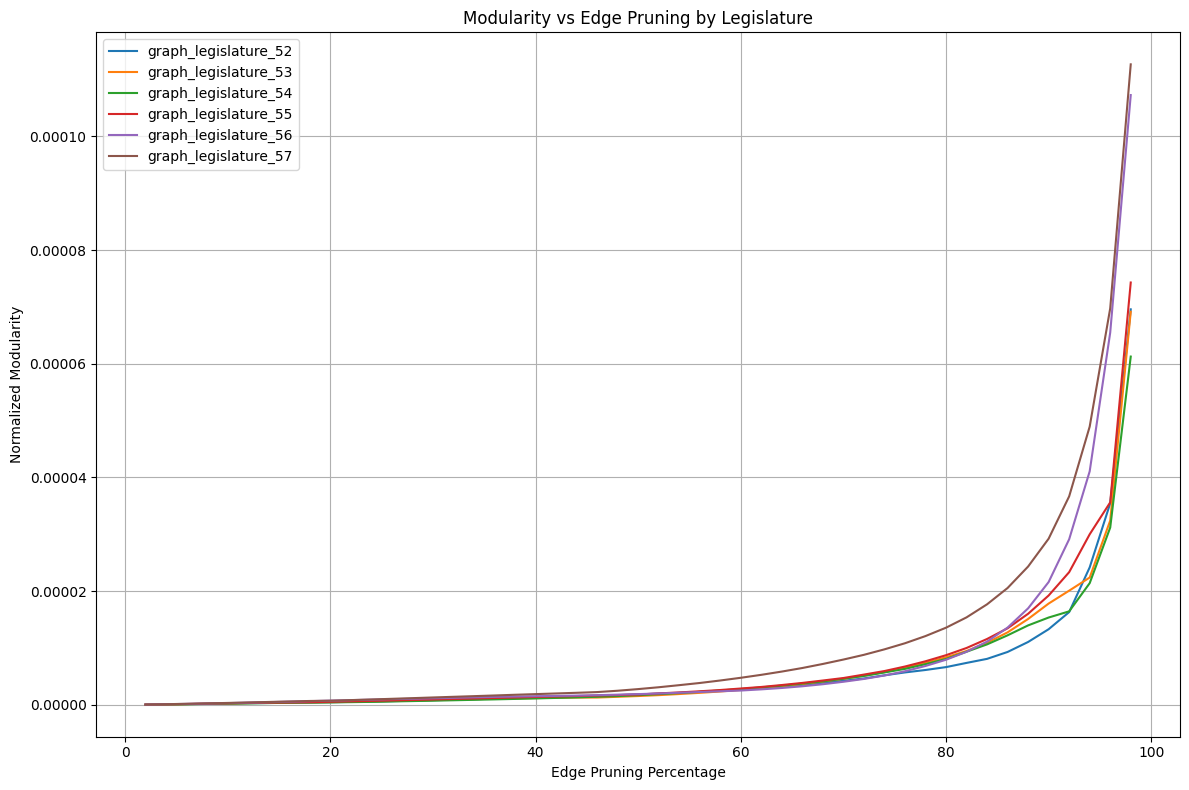

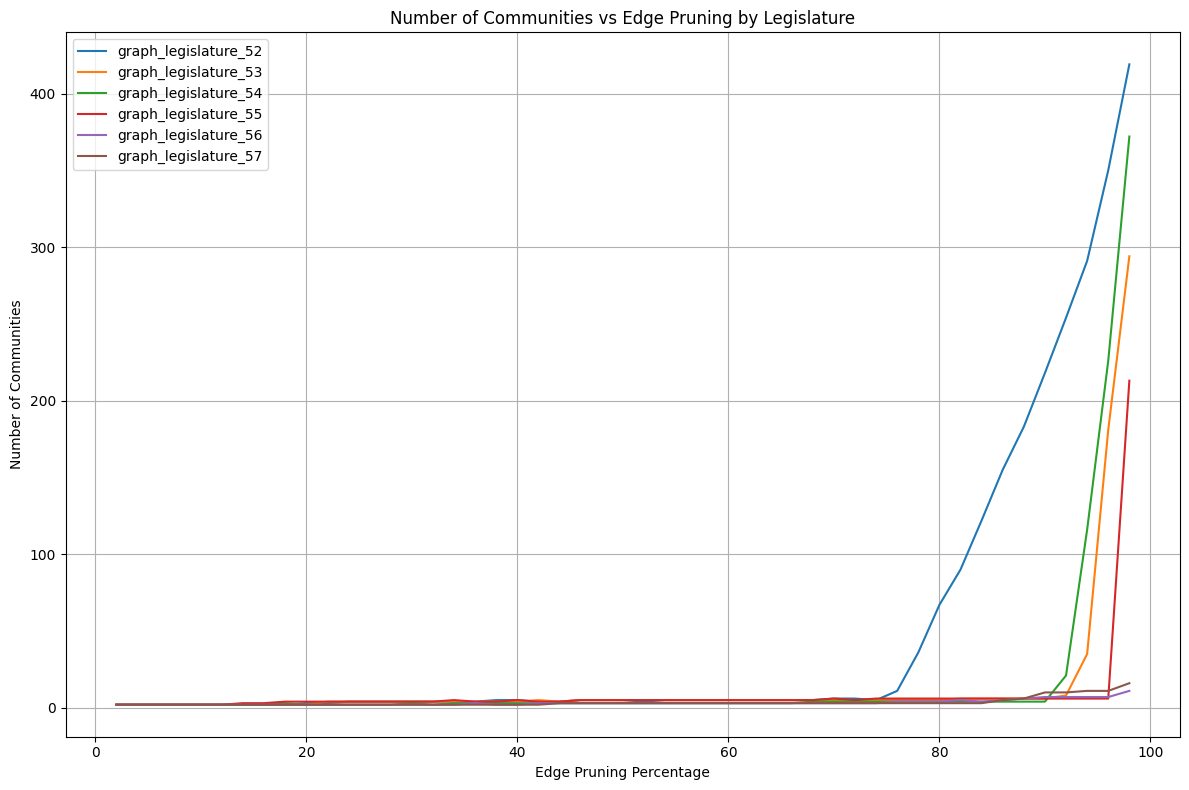

In [22]:
# Visualize modularity results
plt.figure(figsize=(12, 8))
for legislature, data in modularity_results.items():
    plt.plot(data['cut_percentages'], data['modularity_values'], label=legislature)
    
plt.xlabel('Edge Pruning Percentage')
plt.ylabel('Normalized Modularity')
plt.title('Modularity vs Edge Pruning by Legislature')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# Visualize number of communities
plt.figure(figsize=(12, 8))
for legislature, data in modularity_results.items():
    plt.plot(data['cut_percentages'], data['num_communities'], label=legislature)
    
plt.xlabel('Edge Pruning Percentage')
plt.ylabel('Number of Communities')
plt.title('Number of Communities vs Edge Pruning by Legislature')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


In [23]:
# Load the results from CSV
results_df = pd.read_csv('community_analysis_results.csv')

# Filter results where number of communities > 1
filtered_df = results_df[results_df['num_communities'] > 1].copy()

# For each legislature, find the configuration with highest modularity 
# among those with the minimum number of communities > 1
optimal_configs = []

for legislature in filtered_df['legislature'].unique():
    leg_data = filtered_df[filtered_df['legislature'] == legislature]
    
    # Find the minimum number of communities for this legislature
    min_communities = leg_data['num_communities'].min()
    
    # Filter to only configurations with minimum number of communities
    min_comm_data = leg_data[leg_data['num_communities'] == min_communities]
    
    # Among these, select the one with highest modularity
    best_config = min_comm_data.loc[min_comm_data['modularity'].idxmax()]
    
    optimal_configs.append({
        'legislature': best_config['legislature'],
        'num_communities': best_config['num_communities'],
        'prune_percent': best_config['prune_percent'],
        'modularity': best_config['modularity']
    })

# Create and display the results table
optimal_df = pd.DataFrame(optimal_configs)
optimal_df = optimal_df.sort_values('legislature')

print("Optimal Community Configurations (Minimum Communities > 1 with Highest Modularity):")
print("=" * 80)
print(optimal_df.to_string(index=False))

# Save to CSV
optimal_df.to_csv('optimal_community_configs.csv', index=False)
print(f"\nResults saved to 'optimal_community_configs.csv'")
print(f"Total legislatures analyzed: {len(optimal_df)}")


Optimal Community Configurations (Minimum Communities > 1 with Highest Modularity):
         legislature  num_communities  prune_percent   modularity
graph_legislature_52                2             18 4.106572e-07
graph_legislature_53                2             20 4.778268e-07
graph_legislature_54                2             32 8.101711e-07
graph_legislature_55                2             12 3.402727e-07
graph_legislature_56                2             40 1.524184e-06
graph_legislature_57                2             42 2.007422e-06

Results saved to 'optimal_community_configs.csv'
Total legislatures analyzed: 6


In [24]:
# Now let's detect and store community assignments for each deputy in the optimal configurations
# Dictionary to store community memberships for each legislature
community_memberships = {}

# Loop through each optimal configuration
for _, config in optimal_df.iterrows():
    legislature = config['legislature']
    prune_percent = config['prune_percent']
    
    print(f"Processing optimal configuration for {legislature} with {prune_percent}% pruning")
    
    # Get the original graph
    graph = graphs[legislature]
    
    # Convert NetworkX graph to igraph again
    # Create mapping of node names to indices
    node_mapping = {node: idx for idx, node in enumerate(graph.nodes())}
    reverse_mapping = {idx: node for node, idx in node_mapping.items()}
    
    # Create edge list with mapped indices
    edge_list = []
    weights = []
    for u, v, data in graph.edges(data=True):
        weight = data.get('weight', 1.0)
        edge_list.append((node_mapping[u], node_mapping[v]))
        weights.append(weight)
    
    # Create igraph object
    g_ig = ig.Graph(n=len(graph.nodes()), directed=False)
    g_ig.add_edges(edge_list)
    g_ig.es['weight'] = weights
    
    # Sort edges by weight (weakest to strongest)
    sorted_edges = sorted(zip(g_ig.es.indices, weights), key=lambda x: x[1])
    edge_indices = [edge_idx for edge_idx, _ in sorted_edges]
    
    # Calculate number of edges to remove
    total_edges = len(edge_indices)
    edges_to_remove = int(total_edges * prune_percent / 100)
    
    # Create a copy of the graph
    g_temp = g_ig.copy()
    
    # Remove the weakest edges
    if edges_to_remove > 0:
        edges_to_remove_indices = edge_indices[:edges_to_remove]
        g_temp.delete_edges(edges_to_remove_indices)
    
    # Detect communities using Leiden algorithm
    partition = la.find_partition(g_temp, la.ModularityVertexPartition)
    
    # Store the membership information for each deputy
    memberships = {}
    for vertex_idx, community_id in enumerate(partition.membership):
        deputy_id = reverse_mapping[vertex_idx]
        memberships[deputy_id] = community_id
    
    # Store in the results dictionary
    community_memberships[legislature] = memberships
    
    print(f"Stored community assignments for {len(memberships)} deputies in {legislature}")

print(f"\nCompleted storing community memberships for {len(community_memberships)} legislatures")


Processing optimal configuration for graph_legislature_52 with 18% pruning
Stored community assignments for 582 deputies in graph_legislature_52
Processing optimal configuration for graph_legislature_53 with 20% pruning
Stored community assignments for 598 deputies in graph_legislature_53
Processing optimal configuration for graph_legislature_54 with 32% pruning
Stored community assignments for 630 deputies in graph_legislature_54
Processing optimal configuration for graph_legislature_55 with 12% pruning
Stored community assignments for 610 deputies in graph_legislature_55
Processing optimal configuration for graph_legislature_56 with 40% pruning
Stored community assignments for 596 deputies in graph_legislature_56
Processing optimal configuration for graph_legislature_57 with 42% pruning
Stored community assignments for 590 deputies in graph_legislature_57

Completed storing community memberships for 6 legislatures


In [25]:
# Let's save the community memberships to the original graphs
# Create a directory to store graphs with community data if it doesn't exist
graphs_with_communities_dir = "../../data/graphs_with_communities"
os.makedirs(graphs_with_communities_dir, exist_ok=True)

# Add community information to each graph and save it
for legislature, memberships in community_memberships.items():
    # Get the original graph
    graph = graphs[legislature]
    
    # Add community as a node attribute
    nx.set_node_attributes(graph, memberships, 'community')
    
    # Save the updated graph
    output_path = os.path.join(graphs_with_communities_dir, f"{legislature}_with_communities.gpickle")
    with open(output_path, 'wb') as f:
        pickle.dump(graph, f)
    
    print(f"Saved {legislature} graph with community data to {output_path}")

print(f"\nAll graphs with community data saved to {graphs_with_communities_dir}")


Saved graph_legislature_52 graph with community data to ../../data/graphs_with_communities\graph_legislature_52_with_communities.gpickle
Saved graph_legislature_53 graph with community data to ../../data/graphs_with_communities\graph_legislature_53_with_communities.gpickle
Saved graph_legislature_54 graph with community data to ../../data/graphs_with_communities\graph_legislature_54_with_communities.gpickle
Saved graph_legislature_55 graph with community data to ../../data/graphs_with_communities\graph_legislature_55_with_communities.gpickle
Saved graph_legislature_56 graph with community data to ../../data/graphs_with_communities\graph_legislature_56_with_communities.gpickle
Saved graph_legislature_57 graph with community data to ../../data/graphs_with_communities\graph_legislature_57_with_communities.gpickle

All graphs with community data saved to ../../data/graphs_with_communities


In [26]:
# Create a consolidated dataframe with deputy community information
community_data = []

for legislature, memberships in community_memberships.items():
    for deputy_id, community_id in memberships.items():
        community_data.append({
            'legislature': legislature,
            'deputy_id': deputy_id,
            'community_id': community_id
        })

# Convert to DataFrame
community_df = pd.DataFrame(community_data)

# Display information about the DataFrame
print("Community assignments summary:")
print(f"Total rows: {len(community_df)}")
print(f"Unique legislatures: {community_df['legislature'].nunique()}")
print(f"Unique deputies: {community_df['deputy_id'].nunique()}")

# Summary statistics by legislature
legislature_summary = community_df.groupby('legislature').agg(
    num_deputies=('deputy_id', 'nunique'),
    num_communities=('community_id', 'nunique')
)

print("\nSummary by legislature:")
print(legislature_summary)

# Save the DataFrame to CSV
community_df.to_csv('deputy_community_assignments.csv', index=False)
print("\nSaved deputy community assignments to 'deputy_community_assignments.csv'")


Community assignments summary:
Total rows: 3606
Unique legislatures: 6
Unique deputies: 1962

Summary by legislature:
                      num_deputies  num_communities
legislature                                        
graph_legislature_52           582                2
graph_legislature_53           598                2
graph_legislature_54           630                3
graph_legislature_55           610                2
graph_legislature_56           596                2
graph_legislature_57           590                2

Saved deputy community assignments to 'deputy_community_assignments.csv'


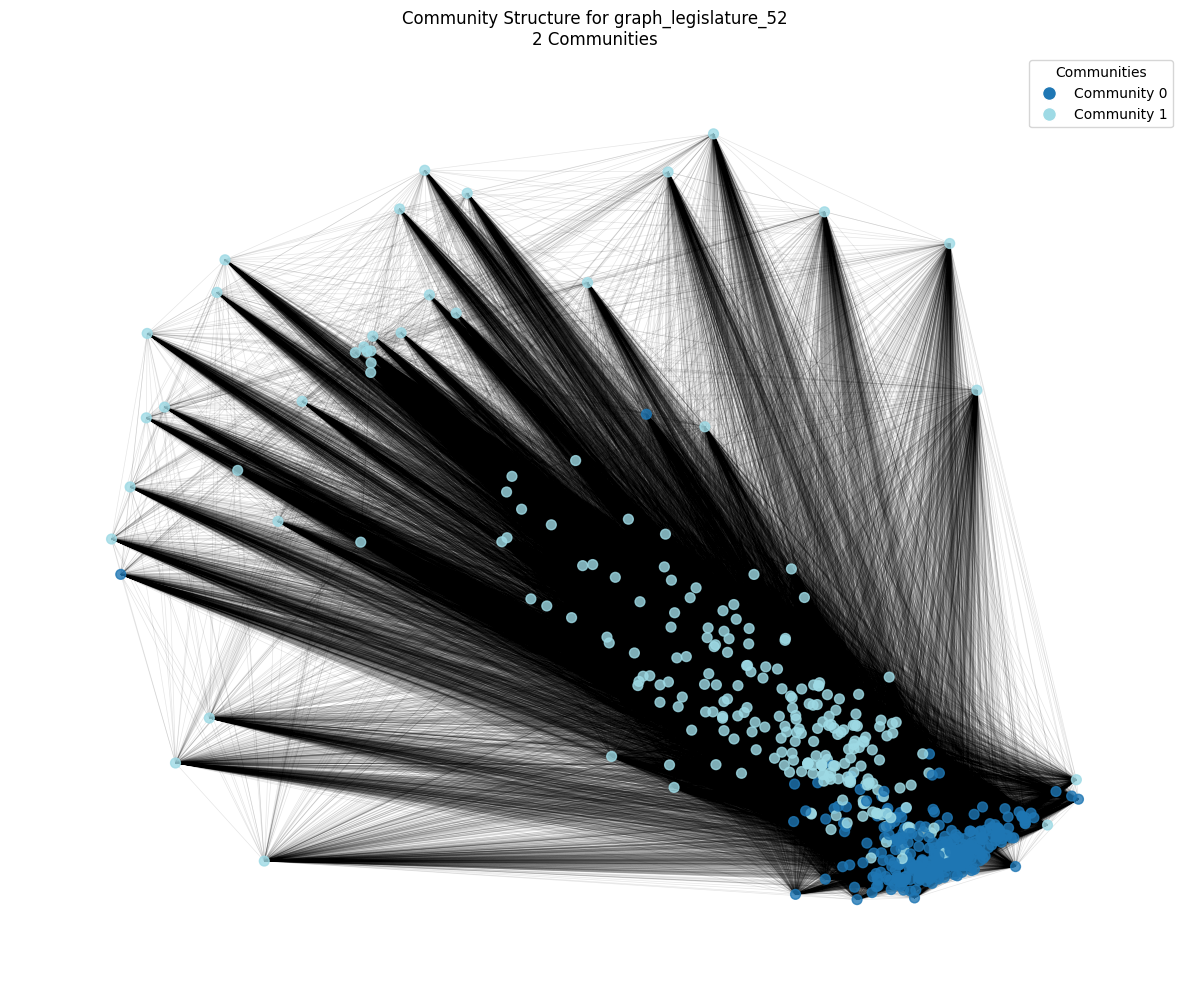

Community sizes for graph_legislature_52:
Community 0: 330 deputies (56.7%)
Community 1: 252 deputies (43.3%)


In [27]:
# Function to visualize community structure for a specific legislature
def visualize_community_structure(legislature):
    if legislature not in graphs:
        print(f"Error: {legislature} not found in loaded graphs")
        return
    
    if legislature not in community_memberships:
        print(f"Error: {legislature} not found in community memberships")
        return
    
    # Get the graph and memberships
    graph = graphs[legislature]
    memberships = community_memberships[legislature]
    
    # Create a layout for the graph
    pos = nx.spring_layout(graph, seed=42)
    
    # Get unique communities and assign colors
    unique_communities = set(memberships.values())
    colors = plt.cm.tab20(np.linspace(0, 1, len(unique_communities)))
    community_colors = {comm: colors[i] for i, comm in enumerate(unique_communities)}
    
    # Assign colors to nodes based on community
    node_colors = [community_colors[memberships[node]] for node in graph.nodes()]
    
    # Plot the graph
    plt.figure(figsize=(12, 10))
    
    # Draw nodes
    nx.draw_networkx_nodes(
        graph, pos, 
        node_size=50, 
        node_color=node_colors,
        alpha=0.8
    )
    
    # Draw edges with transparency based on weight
    edge_weights = [data.get('weight', 1.0) for _, _, data in graph.edges(data=True)]
    max_weight = max(edge_weights)
    
    # Normalize weights for transparency
    edge_alphas = [min(0.8, max(0.1, weight/max_weight)) for weight in edge_weights]
    
    # Draw edges
    nx.draw_networkx_edges(
        graph, pos, 
        width=0.5, 
        alpha=0.1  # Low overall transparency
    )
    
    plt.title(f"Community Structure for {legislature}\n{len(unique_communities)} Communities")
    plt.axis('off')
    plt.tight_layout()
    
    # Add legend for communities
    legend_elements = [plt.Line2D([0], [0], marker='o', color='w', 
                                 markerfacecolor=community_colors[comm], 
                                 markersize=10, 
                                 label=f'Community {comm}') 
                      for comm in sorted(unique_communities)]
    
    plt.legend(handles=legend_elements, loc='upper right', title="Communities")
    
    plt.show()
    
    # Print community statistics
    community_sizes = defaultdict(int)
    for comm in memberships.values():
        community_sizes[comm] += 1
        
    print(f"Community sizes for {legislature}:")
    for comm, size in sorted(community_sizes.items()):
        print(f"Community {comm}: {size} deputies ({size/len(memberships)*100:.1f}%)")

# Example visualization for one legislature (you can change this to visualize any legislature)
if len(community_memberships) > 0:
    sample_legislature = list(community_memberships.keys())[0]
    visualize_community_structure(sample_legislature)


In [28]:
# Load saved graphs with community information
def load_community_graphs():
    """
    Load the graphs with community information
    """
    graphs_with_communities_dir = "../../data/graphs_with_communities"
    
    # Check if directory exists
    if not os.path.exists(graphs_with_communities_dir):
        print(f"Directory not found: {graphs_with_communities_dir}")
        return {}
    
    # List all files in the directory
    graph_files = os.listdir(graphs_with_communities_dir)
    
    # Load all graphs with community information
    community_graphs = {}
    for file in graph_files:
        if file.endswith('.gpickle'):
            file_path = os.path.join(graphs_with_communities_dir, file)
            try:
                graph_name = os.path.splitext(file)[0]  # Remove file extension
                with open(file_path, 'rb') as f:
                    community_graphs[graph_name] = pickle.load(f)
                print(f"Loaded graph with communities: {graph_name}")
            except Exception as e:
                print(f"Error loading {file}: {e}")
    
    # Display information about loaded graphs
    print(f"\nTotal community graphs loaded: {len(community_graphs)}")
    for name, graph in community_graphs.items():
        # Check if community attribute exists
        has_community = any('community' in graph.nodes[node] for node in list(graph.nodes())[:5])
        print(f"{name}: {graph.number_of_nodes()} nodes, {graph.number_of_edges()} edges, has community info: {has_community}")
    
    return community_graphs

# You can uncomment this to load saved graphs with community information
# community_graphs = load_community_graphs()


In [29]:
# Summary of what we've done
print("Community Analysis Summary")
print("=" * 50)
print(f"1. Analyzed {len(graphs)} legislature graphs")
print(f"2. Identified optimal community configurations for each legislature")
print(f"3. Extracted community memberships for each deputy in each legislature")
print(f"4. Saved graphs with community information for future use")
print(f"5. Created a consolidated dataframe with deputy community assignments")

print("\nFiles created:")
print("- community_analysis_results.csv: Detailed analysis results for all pruning percentages")
print("- optimal_community_configs.csv: Best community configuration for each legislature")
print("- deputy_community_assignments.csv: Community assignment for each deputy")
if 'df' in locals() and not df.empty and 'vote_agreement' in locals():
    print("- community_vote_agreement.csv: Vote agreement percentages within communities")

print("\nGraphs with community data saved to: ../../data/graphs_with_communities/")

print("\nNext steps could include:")
print("1. Building predictive models using community assignments as features")
print("2. Analyzing how community structure evolves across legislatures")
print("3. Investigating the relationship between communities and political parties")
print("4. Using community structure for targeted voting analysis or prediction")


Community Analysis Summary
1. Analyzed 6 legislature graphs
2. Identified optimal community configurations for each legislature
3. Extracted community memberships for each deputy in each legislature
4. Saved graphs with community information for future use
5. Created a consolidated dataframe with deputy community assignments

Files created:
- community_analysis_results.csv: Detailed analysis results for all pruning percentages
- optimal_community_configs.csv: Best community configuration for each legislature
- deputy_community_assignments.csv: Community assignment for each deputy

Graphs with community data saved to: ../../data/graphs_with_communities/

Next steps could include:
1. Building predictive models using community assignments as features
2. Analyzing how community structure evolves across legislatures
3. Investigating the relationship between communities and political parties
4. Using community structure for targeted voting analysis or prediction


In [43]:
# FINAL DEBUG SOLUTION: Add previous legislature community information with detailed debugging

# Load the voting dataset again
print("Loading voting dataset...")
df_votes = pd.read_csv('votacoes_full.csv')
print(f"Original dataset shape: {df_votes.shape}")

# Load the community graphs
print("\nLoading community graphs...")
graphs_with_communities_dir = "../../data/graphs_with_communities"

if not os.path.exists(graphs_with_communities_dir):
    print(f"Error: Directory {graphs_with_communities_dir} not found")
else:
    # List and load graph files
    graph_files = [f for f in os.listdir(graphs_with_communities_dir) if f.endswith('.gpickle')]
    print(f"Found {len(graph_files)} graph files")
    
    # Load all graphs
    community_graphs = {}
    for file in graph_files:
        file_path = os.path.join(graphs_with_communities_dir, file)
        try:
            graph_name = os.path.splitext(file)[0].replace('_with_communities', '')
            with open(file_path, 'rb') as f:
                community_graphs[graph_name] = pickle.load(f)
            print(f"Loaded graph: {graph_name}")
        except Exception as e:
            print(f"Error loading {file}: {e}")
    
    # Extract community data from graphs with detailed node ID inspection
    print("\nExtracting community data with detailed node ID inspection...")
    community_data = []
    
    # Debug counters
    int_nodes = 0
    float_nodes = 0
    str_nodes = 0
    other_nodes = 0
    
    for graph_name, graph in community_graphs.items():
        # Extract legislature number
        match = re.search(r'(\d+)', graph_name)
        if not match:
            print(f"Warning: Could not extract legislature number from {graph_name}")
            continue
            
        legislature_num = int(match.group(1))
        
        # Debug: Print node type information for this graph
        node_types = {}
        for node in list(graph.nodes())[:20]:  # Sample first 20 nodes
            node_type = type(node).__name__
            if node_type not in node_types:
                node_types[node_type] = []
            if len(node_types[node_type]) < 5:  # Store up to 5 examples per type
                node_types[node_type].append(str(node))
                
        print(f"\nGraph {graph_name} node types:")
        for node_type, examples in node_types.items():
            print(f"  - {node_type}: {examples}")
        
        # Get community assignments with type tracking
        for node, attrs in graph.nodes(data=True):
            if 'community' in attrs:
                # Track node types for debugging
                if isinstance(node, int):
                    int_nodes += 1
                elif isinstance(node, float):
                    float_nodes += 1
                elif isinstance(node, str):
                    str_nodes += 1
                else:
                    other_nodes += 1
                
                # Store as standardized string
                node_str = str(node)
                
                community_data.append({
                    'legislature': graph_name,
                    'legislature_num': legislature_num,
                    'deputy_id': node,  # Original node
                    'deputy_id_str': node_str,  # String representation
                    'community_id': attrs['community']
                })
    
    print(f"\nNode type statistics across all graphs:")
    print(f"Int nodes: {int_nodes}")
    print(f"Float nodes: {float_nodes}")
    print(f"String nodes: {str_nodes}")
    print(f"Other type nodes: {other_nodes}")
    
    # Create DataFrame with community data
    graph_community_df = pd.DataFrame(community_data)
    print(f"\nCreated community DataFrame with {len(graph_community_df)} entries")
    
    # Standardize voting dataset IDs
    print("\nStandardizing voting dataset IDs...")
    votes_copy = df_votes.copy()
    votes_copy['legislatura'] = votes_copy['legislatura'].astype(int)
    votes_copy['prev_legislature'] = votes_copy['legislatura'] - 1
    
    # Convert voting dataset IDs to string for consistent matching
    votes_copy['deputy_id_str'] = votes_copy['idDeputadoAutor'].apply(
        lambda x: str(int(float(x))) if pd.notna(x) else None
    )
    
    # Sample conversion for demonstration
    sample_conversions = pd.DataFrame({
        'Original': votes_copy['idDeputadoAutor'].head(5),
        'Converted': votes_copy['deputy_id_str'].head(5)
    })
    print("Sample ID conversions:")
    print(sample_conversions)
    
    # Create lookup dictionary using string representation for both keys
    print("\nCreating lookup dictionary with string IDs...")
    community_lookup = {}
    for _, row in graph_community_df.iterrows():
        deputy_id_str = row['deputy_id_str']
        leg_num = row['legislature_num']
        community = row['community_id']
        community_lookup[(deputy_id_str, leg_num)] = community
    
    # Sample of lookup dictionary
    lookup_sample = list(community_lookup.items())[:5]
    print(f"Sample from lookup dictionary: {lookup_sample}")
    
    # Test specific author IDs with detailed output
    print("\nDetailed lookup tests:")
    test_ids = votes_copy['deputy_id_str'].dropna().sample(5).tolist()
    
    for test_id in test_ids:
        print(f"\nTesting deputy ID: {test_id}")
        # Try all legislatures
        for leg in sorted(graph_community_df['legislature_num'].unique()):
            lookup_key = (test_id, leg)
            result = community_lookup.get(lookup_key)
            print(f"  Legislature {leg}: {result}")
    
    # Create a debug function to check lookup
    def get_community_debug(deputy_id_str, legislature_num):
        key = (deputy_id_str, legislature_num)
        result = community_lookup.get(key)
        if result is None:
            # Check for existence in any legislature
            keys_with_deputy = [k for k in community_lookup.keys() if k[0] == deputy_id_str]
            if keys_with_deputy:
                found_legs = [k[1] for k in keys_with_deputy]
                return f"Not found in leg {legislature_num}, but found in legs {found_legs}"
            else:
                return f"Not found in any legislature"
        return result
    
    # Apply the function with debugging
    print("\nAssigning previous communities with debug...")
    
    # Create a sample for detailed debugging
    sample_rows = votes_copy.sample(10)
    debug_results = []
    
    for _, row in sample_rows.iterrows():
        deputy_id_str = row['deputy_id_str']
        prev_legislature = row['prev_legislature']
        
        debug_result = {
            'deputy_id': row['idDeputadoAutor'],
            'deputy_id_str': deputy_id_str,
            'legislature': row['legislatura'],
            'prev_legislature': prev_legislature,
            'lookup_result': get_community_debug(deputy_id_str, prev_legislature)
        }
        debug_results.append(debug_result)
    
    debug_df = pd.DataFrame(debug_results)
    print("Debug lookup results:")
    print(debug_df)
    
    # Apply the function to all rows
    votes_copy['author_prev_community'] = votes_copy.apply(
        lambda row: community_lookup.get((row['deputy_id_str'], row['prev_legislature'])), 
        axis=1
    )
    
    # Print summary statistics
    found_count = votes_copy['author_prev_community'].notna().sum()
    missing_count = votes_copy['author_prev_community'].isna().sum()
    
    print(f"\nCommunity assignment statistics:")
    print(f"Found community: {found_count} rows ({found_count/len(votes_copy)*100:.1f}%)")
    print(f"Missing community: {missing_count} rows ({missing_count/len(votes_copy)*100:.1f}%)")
    
    # For rows missing communities, print detailed analysis
    missing_analysis = votes_copy[votes_copy['author_prev_community'].isna()].groupby('legislatura').size()
    print("\nMissing community by legislature:")
    print(missing_analysis)
    
    # Sample of rows with assigned communities
    print("\nSample of rows with assigned communities:")
    community_sample = votes_copy[votes_copy['author_prev_community'].notna()].sample(5)
    print(community_sample[['idDeputadoAutor', 'deputy_id_str', 'legislatura', 'prev_legislature', 'author_prev_community']])
    
    # Clean up and save
    final_df = votes_copy.drop(columns=['deputy_id_str', 'prev_legislature'])
    final_df.to_csv('votacoes_full_with_communities_debug.csv', index=False)
    print(f"\nSaved updated dataset to 'votacoes_full_with_communities_debug.csv'")
    
    # Additional debugging for specific author IDs
    if len(community_lookup) > 0:
        print("\nDEBUG: Checking all deputies with missing communities in a sample legislature...")
        sample_leg = 53  # Use legislature 53 as an example
        deputies_missing = votes_copy[
            (votes_copy['legislatura'] == sample_leg + 1) & 
            (votes_copy['author_prev_community'].isna())
        ]['deputy_id_str'].unique()
        
        if len(deputies_missing) > 0:
            print(f"Found {len(deputies_missing)} unique deputies with missing communities in legislature {sample_leg + 1}")
            
            # Check a sample of these deputies
            for deputy in deputies_missing[:5]:
                print(f"\nChecking deputy {deputy}:")
                
                # Check if this deputy exists in the graph for the previous legislature
                deputy_in_graph = any(
                    (row['legislature_num'] == sample_leg) and 
                    (row['deputy_id_str'] == deputy)
                    for _, row in graph_community_df.iterrows()
                )
                
                print(f"  Exists in legislature {sample_leg} graph: {deputy_in_graph}")
                
                # Check in which legislatures this deputy does exist
                found_legs = [
                    row['legislature_num']
                    for _, row in graph_community_df[graph_community_df['deputy_id_str'] == deputy].iterrows()
                ]
                
                if found_legs:
                    print(f"  Found in legislatures: {sorted(found_legs)}")
                else:
                    print(f"  Not found in any legislature graph")


Loading voting dataset...
Original dataset shape: (78814, 20)

Loading community graphs...
Found 6 graph files
Loaded graph: graph_legislature_52
Loaded graph: graph_legislature_53
Loaded graph: graph_legislature_54
Loaded graph: graph_legislature_55
Loaded graph: graph_legislature_56
Loaded graph: graph_legislature_57

Extracting community data with detailed node ID inspection...

Graph graph_legislature_52 node types:
  - str: ['129617', '129618', '133370', '133371', '133372']

Graph graph_legislature_53 node types:
  - str: ['129618', '131873', '132056', '133372', '133373']

Graph graph_legislature_54 node types:
  - str: ['104254', '109152', '109372', '114586', '116663']

Graph graph_legislature_55 node types:
  - str: ['101309', '105112', '112437', '113247', '114941']

Graph graph_legislature_56 node types:
  - str: ['105534', '107283', '108338', '109429', '112437']

Graph graph_legislature_57 node types:
  - str: ['100689', '103758', '104552', '107283', '107970']

Node type stati

In [44]:
# Add community size information to the dataset

# Load the dataset with communities
print("Loading dataset with communities...")
df_with_communities = pd.read_csv('votacoes_full_with_communities_debug.csv')
print(f"Dataset shape: {df_with_communities.shape}")

# Calculate community sizes for each legislature
print("\nCalculating community sizes for each legislature...")
community_sizes = {}

for legislature_num in sorted(graph_community_df['legislature_num'].unique()):
    # Filter community data for this legislature
    leg_data = graph_community_df[graph_community_df['legislature_num'] == legislature_num]
    
    # Count deputies in each community
    community_counts = leg_data['community_id'].value_counts().to_dict()
    
    # Store in the dictionary
    community_sizes[legislature_num] = community_counts
    
    print(f"Legislature {legislature_num}: {community_counts}")

# Add community size columns to the dataset
print("\nAdding community size columns...")
df_with_communities['prev_legislature'] = df_with_communities['legislatura'] - 1

# Create a function to get community size
def get_community_size(leg_num, comm_id):
    if leg_num not in community_sizes:
        return None
    return community_sizes[leg_num].get(comm_id, 0)

# Add columns for community 0 and 1 sizes
df_with_communities['prev_community_0_size'] = df_with_communities['prev_legislature'].apply(
    lambda leg: get_community_size(leg, 0)
)

df_with_communities['prev_community_1_size'] = df_with_communities['prev_legislature'].apply(
    lambda leg: get_community_size(leg, 1)
)

# For legislature 54, also add community 2 size (since it has 3 communities)
if 2 in graph_community_df[graph_community_df['legislature_num'] == 54]['community_id'].unique():
    df_with_communities['prev_community_2_size'] = df_with_communities['prev_legislature'].apply(
        lambda leg: get_community_size(leg, 2) if leg == 54 else 0
    )

# Clean up the final dataset
final_df = df_with_communities.drop(columns=['prev_legislature'])

# Show summary of added columns
print("\nCommunity size columns summary:")
print(f"prev_community_0_size: {final_df['prev_community_0_size'].notna().sum()} non-null values")
print(f"prev_community_1_size: {final_df['prev_community_1_size'].notna().sum()} non-null values")
if 'prev_community_2_size' in final_df.columns:
    print(f"prev_community_2_size: {final_df['prev_community_2_size'].notna().sum()} non-null values")

# Save the updated dataset
final_df.to_csv('votacoes_full_with_communities_complete.csv', index=False)
print(f"\nSaved updated dataset to 'votacoes_full_with_communities_complete.csv' with shape {final_df.shape}")

# Show a sample of rows with community sizes
print("\nSample rows with community sizes:")
sample_rows = final_df[final_df['author_prev_community'].notna()].sample(5)
display_cols = ['idDeputadoAutor', 'legislatura', 'author_prev_community', 
                'prev_community_0_size', 'prev_community_1_size']
if 'prev_community_2_size' in final_df.columns:
    display_cols.append('prev_community_2_size')
print(sample_rows[display_cols])


Loading dataset with communities...
Dataset shape: (78814, 21)

Calculating community sizes for each legislature...
Legislature 52: {0: 330, 1: 252}
Legislature 53: {0: 398, 1: 200}
Legislature 54: {0: 348, 1: 274, 2: 8}
Legislature 55: {0: 348, 1: 262}
Legislature 56: {0: 441, 1: 155}
Legislature 57: {0: 392, 1: 198}

Adding community size columns...

Community size columns summary:
prev_community_0_size: 73170 non-null values
prev_community_1_size: 73170 non-null values
prev_community_2_size: 78814 non-null values

Saved updated dataset to 'votacoes_full_with_communities_complete.csv' with shape (78814, 24)

Sample rows with community sizes:
       idDeputadoAutor  legislatura  author_prev_community  \
13827          74061.0           53                    1.0   
42388         160592.0           56                    1.0   
15800          74842.0           53                    0.0   
47007         141398.0           56                    1.0   
15068          73586.0           53   